### The transient Universe:


Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [1]:
import numpy as np
from scipy import stats 
import matplotlib.pyplot as plt
import emcee
import pymc
import corner
import dynesty 

In [2]:
data = np.load('transient.npy')
time = data[:,0]
signal = data[:,1]
err = data[:,2]

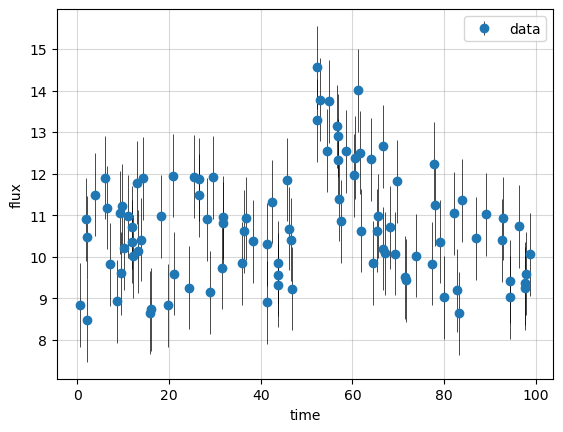

In [3]:
plt.errorbar(time, signal, err, label = 'data', ecolor='k', elinewidth = 0.5, marker = 'o', linestyle='none')
plt.xlabel('time')
plt.ylabel('flux')
plt.grid(c = 'gray', alpha = 0.3)
plt.legend()

Let's define our two models: the burst model and the gaussian model. 

We also try to visualize which one could be the 'better' one by using some test paramaters. 

In [4]:
def burst_model(theta, time):
    A, b, alpha, t0 = theta
    y = np.zeros_like(time)
    y[time < t0] = b
    y[time >= t0] = b + A * np.exp(-alpha * (time[time >= t0] - t0))
    return y
    
def gauss_model(theta, time):
    A, b, sigmaW, t0 = theta
    return b + A*np.exp(-(time-t0)**2 /(2*sigmaW**2))

x_grid = np.linspace(0, np.max(time), len(time))
theta_burst_test = 7, 9.5, np.exp(-1.7), 50
burst_test = burst_model(theta_burst_test, x_grid)
theta_gauss_test = 6, 9.5, 4.5, 50
gauss_test = gauss_model(theta_gauss_test, x_grid)

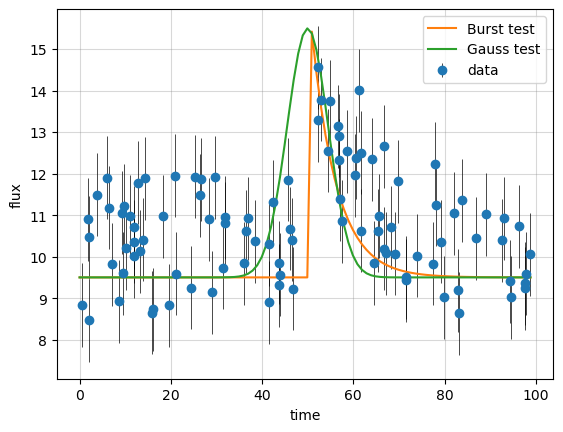

In [5]:
plt.errorbar(time, signal, err, label = 'data', ecolor='k', elinewidth = 0.5, marker = 'o', linestyle='none')
plt.plot(x_grid, burst_test, label = 'Burst test')
plt.plot(x_grid, gauss_test, label = 'Gauss test')
plt.xlabel('time')
plt.ylabel('flux')
plt.grid(c = 'gray', alpha = 0.3)
plt.legend()

We now need to set up the likelihoods and the priors for our models.
Starting from the burst model:

In [6]:
ndim = 4
Amin = bmin = t0min = 0
Amax = bmax = 50
t0max = 100
alphamin = np.exp(-5)
alphamax = np.exp(5)
sigmaWmin = np.exp(-2) #2
sigmaWmax = np.exp(2) #6

#Let's define one single function for both models to run the nested sampling just chainging one param!

def priors(u, model): #The prior here must be given by 'adjusting' the values extracted by the hypercube of size [0,1]
    priors = np.copy(u)
    priors[0] = stats.uniform.ppf(u[0], loc = Amin, scale =Amax-Amin ) #A
    priors[1] = stats.uniform.ppf(u[1], loc = bmin, scale =bmax-bmin ) #b
    priors[3] = stats.uniform.ppf(u[3], loc = t0min, scale =t0max-t0min ) #t0

    if model == 'burts_model':
         priors[2] = stats.loguniform.ppf(u[2], a = alphamin, b = alphamax) #alpha
    elif model == 'gauss_model':
        #priors[2] = stats.uniform.ppf(u[2], loc = sigmaWmin, scale = sigmaWmax-sigmaWmin) #SigmaW
        priors[2] = stats.loguniform.ppf(u[2], sigmaWmin, sigmaWmax) #SigmaW
        
    return priors

def loglh(theta, signal, time, model):  #no normalization as we only care about the ratio between our two models!
    if model == 'burst_model':
        y = burst_model(theta, time)
        return -0.5 * np.sum((signal-y)**2 / 1)
        
    elif model == 'gauss_model':
        y = gauss_model(theta, time)
        return -0.5 * np.sum((signal-y)**2 / 1)

In [7]:
sampler = dynesty.NestedSampler(loglh, priors, ndim, logl_args = [signal, time, 'burst_model'], ptform_args = ['burst_model'], nlive = 300)
sampler.run_nested()
sresults = sampler.results

2135it [00:30, 27.76it/s, bound: 60 | nc: 24 | ncall: 30135 | eff(%):  7.085 | loglstar:   -inf < -85.889 <    inf | logz: -94.794 +/-  0.158 | dlogz: 33.372 >  0.309]     /opt/anaconda3/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2151it [00:31, 12.00it/s, bound: 63 | nc: 10 | ncall: 31325 | eff(%):  6.867 | loglstar:   -inf < -84.935 <    inf | logz: -94.338 +/-  0.161 | dlogz: 32.876 >  0.309]/opt/anaconda3/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using 

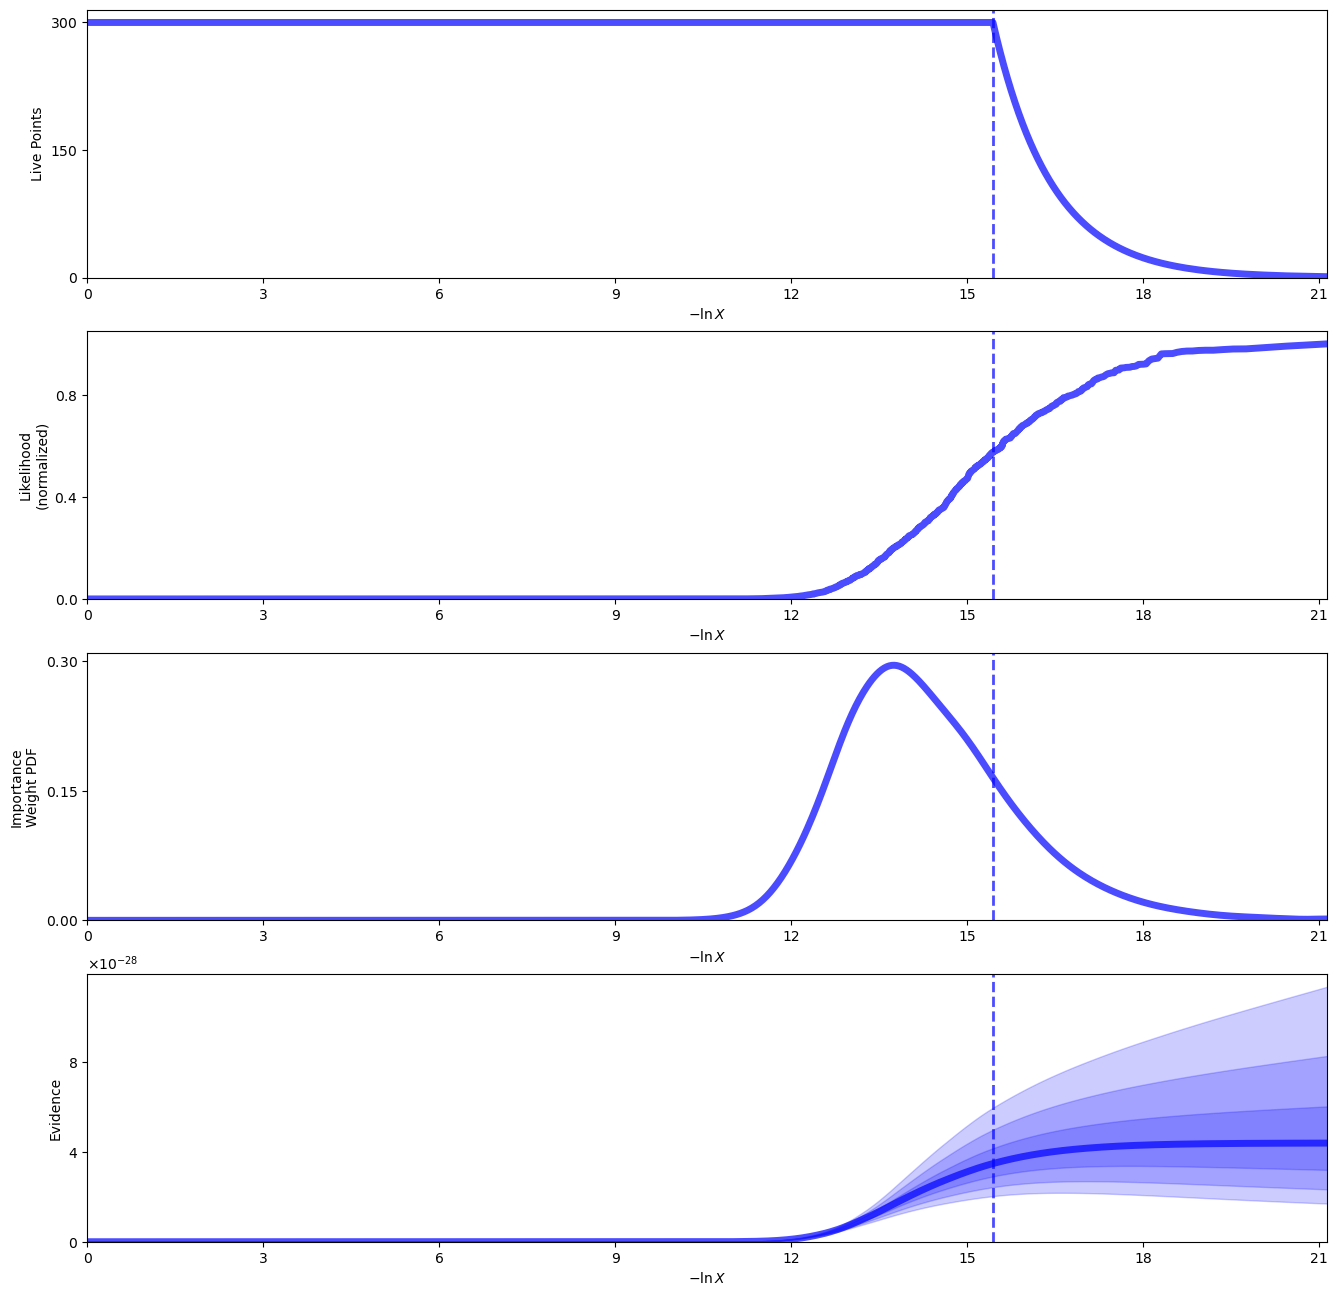

In [8]:
from dynesty import plotting as dyplot

rfig, raxes = dyplot.runplot(sresults)

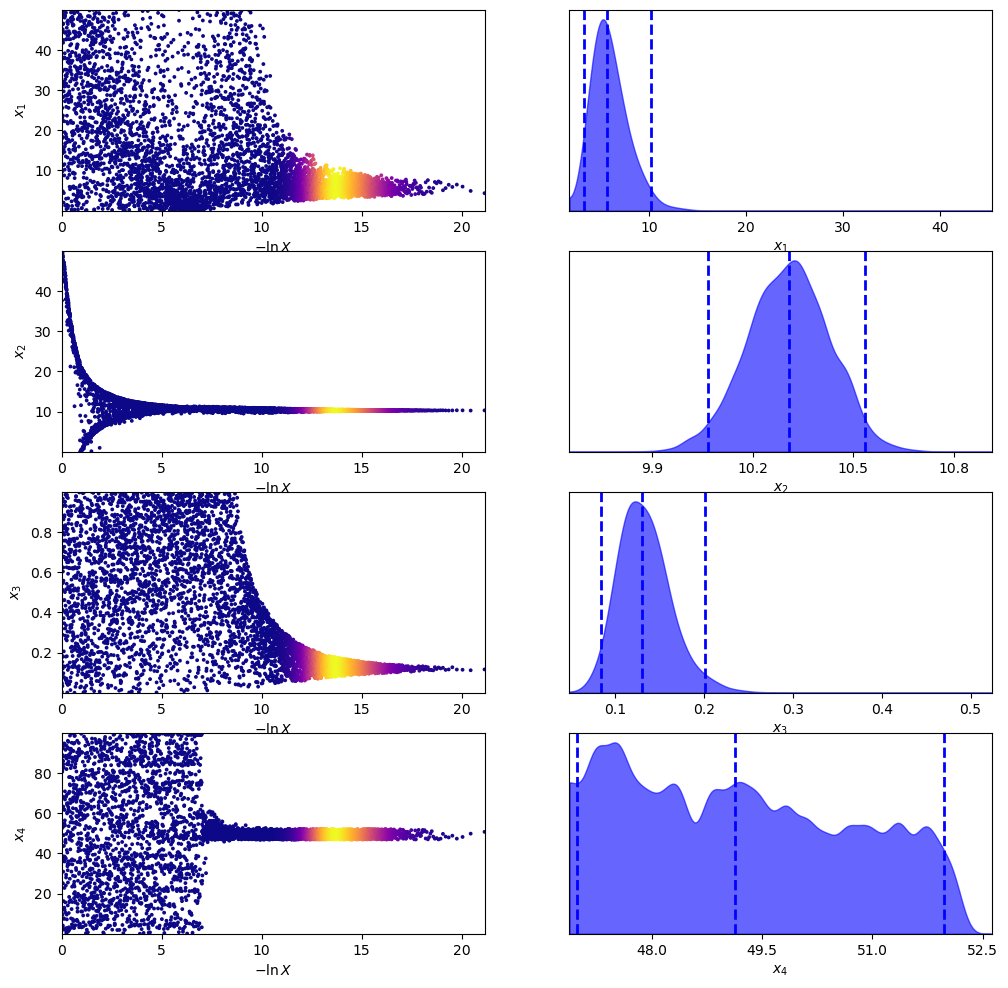

In [9]:
tfig, taxes = dyplot.traceplot(sresults)

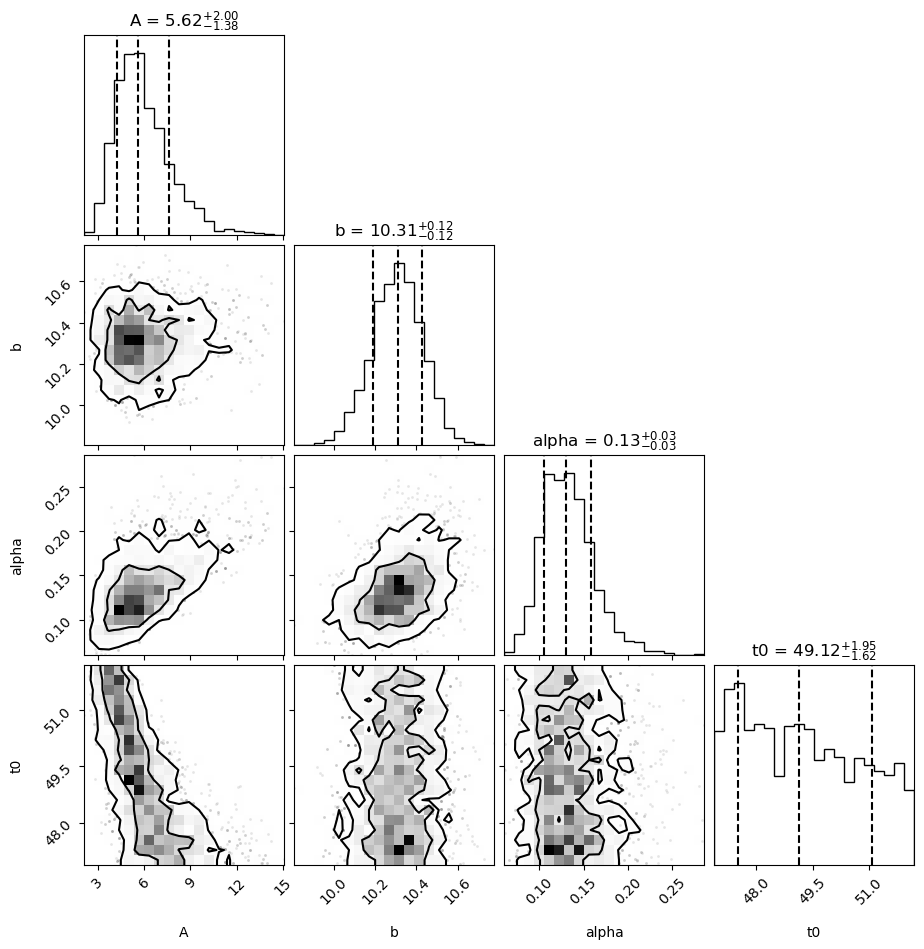

In [10]:
#Let's check if the corner plot of our parmas is simialr to the one found using MCMC:
from dynesty import utils as dyfunc

samples = sresults.samples 
weights = np.exp(sresults.logwt - sresults.logz[-1])
labels = ['A', 'b', 'alpha', 't0']
b_evidence = np.exp(sresults.logz[-1]) #Burst model evidence - we'll need it later 

samples_noweight = dyfunc.resample_equal(samples, weights)
corner.corner(samples_noweight, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True);

best_thetsab = np.array([np.mean(samples_noweight[:,i]) for i in range(ndim)])

It does look very similar to the old corner plot we got from our last exercise! 

Let's now move to the Gaussian Model!

In [11]:
sampler = dynesty.NestedSampler(loglh, priors, ndim, logl_args = [signal, time, 'gauss_model'], ptform_args = ['gauss_model'], nlive = 300)
sampler.run_nested()
sresults = sampler.results

2451it [01:03,  3.19it/s, bound: 98 | nc: 144 | ncall: 49910 | eff(%):  4.911 | loglstar:   -inf < -86.453 <    inf | logz: -94.446 +/-  0.151 | dlogz: 31.503 >  0.309]    /opt/anaconda3/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2821it [01:32, 10.29it/s, bound: 147 | nc: 33 | ncall: 70575 | eff(%):  3.997 | loglstar:   -inf < -78.135 <    inf | logz: -89.441 +/-  0.183 | dlogz: 25.286 >  0.309] /opt/anaconda3/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are usin

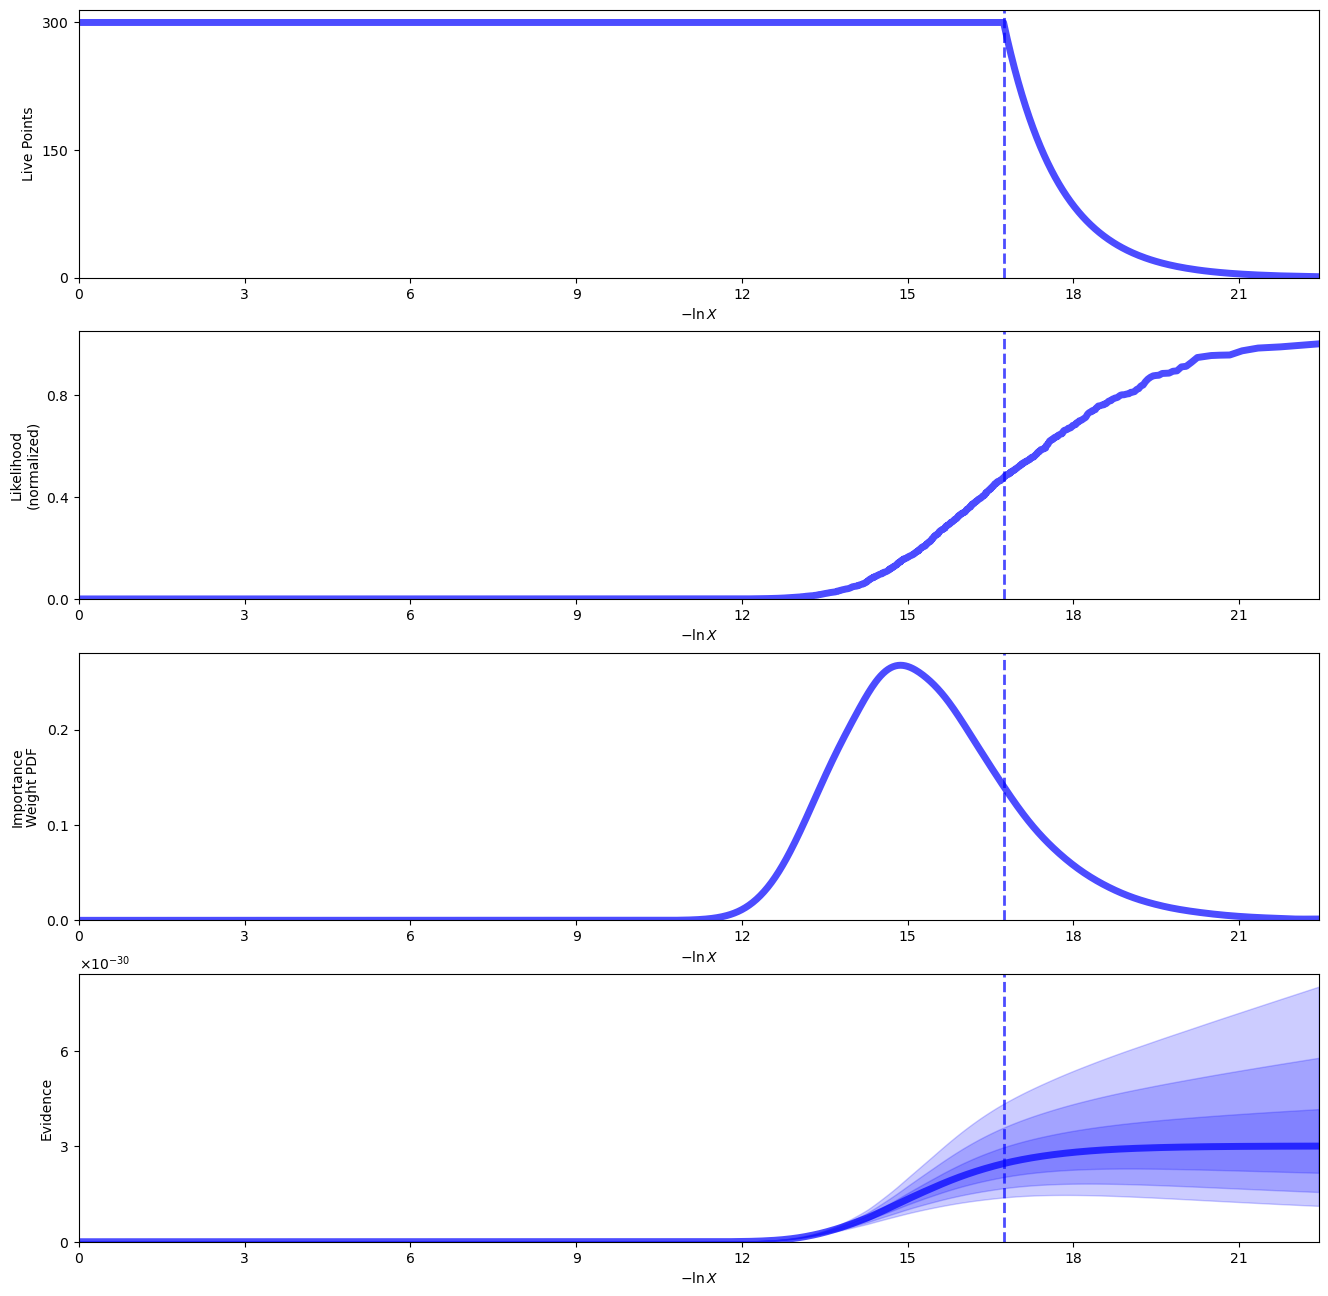

In [12]:
rfig, raxes = dyplot.runplot(sresults)

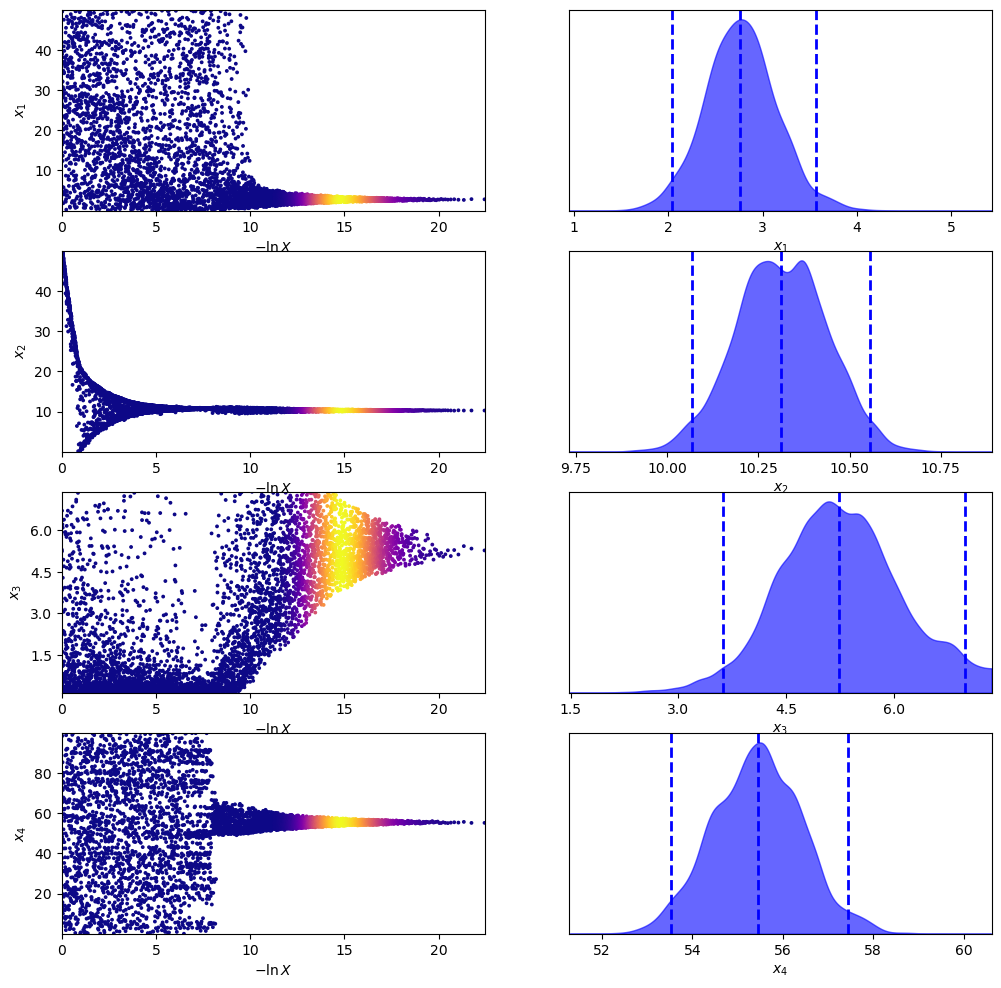

In [13]:
tfig, taxes = dyplot.traceplot(sresults)

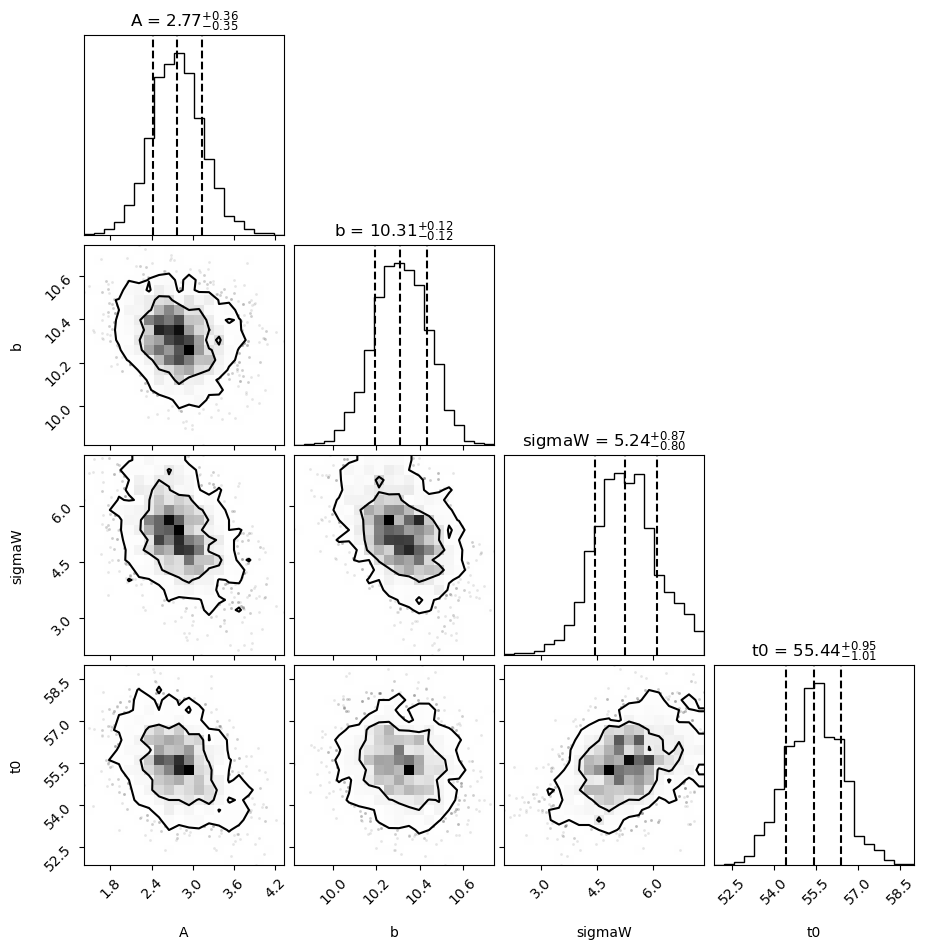

In [14]:
samples = sresults.samples 
weights = np.exp(sresults.logwt - sresults.logz[-1])
labels = ['A', 'b', 'sigmaW', 't0']
g_evidence = np.exp(sresults.logz[-1]) #Gauss model evidence - we'll need it for model selection

samples_noweight = dyfunc.resample_equal(samples, weights)
corner.corner(samples_noweight, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True);

best_thetsag = np.array([np.mean(samples_noweight[:,i]) for i in range(ndim)])

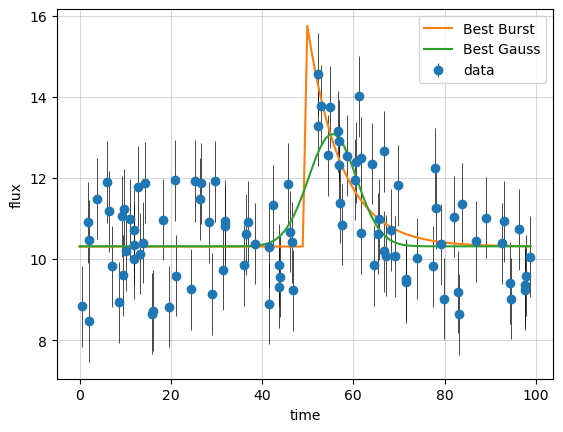

In [15]:
plt.errorbar(time, signal, err, label = 'data', ecolor='k', elinewidth = 0.5, marker = 'o', linestyle='none')
plt.plot(x_grid, burst_model(best_thetsab, x_grid), label = 'Best Burst')
plt.plot(x_grid, gauss_model(best_thetsag, x_grid), label = 'Best Gauss')
plt.xlabel('time')
plt.ylabel('flux')
plt.grid(c = 'gray', alpha = 0.3)
plt.legend()

Let's now compute the ratio between the evidences to find out which model is the 'best'.

In [16]:
odds_ratio = b_evidence/g_evidence
print(odds_ratio)

146.34773151458987


So, according to Jeffreys scale, this is very strong evidence in favor of our burst model! 